# Poprawa Kolokwium 

## Termin realizacji 30.01.2026

Zadaniem tego projektu jest poprawa kolokwium pisanego w trakcie zajęć.
Ponieważ obecna forma poprawy została opracowana jako projekt indywidualny, gdzie posiadają Państwo większą ilość czasu należy wykonać ją **bez użycia jakichkolwiek innych bibliotek/pakietów, niż te, które zostały podane w pakietach podstawowych**

Poniższe zadania mają potwierdzić posiadane przez Państwa umiejętności budowania algorytmów uczenia maszynowego i  modelowania regresji na przykładzie danych zawierających ceny nieruchomości znajdujących się w pliku "domy.csv". W zadaniu należy wykorzystać wiedzę poznaną na laboratorium w tym metody regularyzacji, metody wyboru i tworzenia nowych zmiennych, określenie jakości modelu. Każdy otrzymany wynik ma być opisany stosownymi wnioskami.

Z poprawy można zdobyć 25 pkt. Zdobyte punkty nadpisują punkty zdobyte z kolokwium. Za każde zadanie można dostać od 0 do 5 pkt. Później nastąpi skalownie do 50 pkt.

Można korzystać z dowolnych źródeł.



### !!! Uwaga !!!
**Przesłanie pliku na ISOD potwierdza deklarację samodzielnego wykonania projektu!!!**

**Praca zespołowa czy kopiowanie kodu od kolegów jest zabronione!!!**

**Każda osoba pracuje na innych danych, więc podanie wniosków nieadekwatnych do otrzymanych wyników będzie uznane za próbę ściągania i karane niezaliczeniem kolokwium, a co za tym idzie przedmiotu!!!**


In [18]:
# Wyczanie pakietów podstawowych
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Dodane przeze mnie importy
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Wczytanie danych
dtype_dict = {'bathrooms':float, 'waterfront':int, 'sqft_above':int, 'sqft_living15':float, 'grade':int, 'yr_renovated':int, 'price':float, 'bedrooms':float, 'zipcode':str, 'long':float, 'sqft_lot15':float, 'sqft_living':float, 'floors':str, 'condition':int, 'lat':float, 'date':str, 'sqft_basement':int, 'yr_built':int, 'id':str, 'sqft_lot':int, 'view':int}
domy = pd.read_csv("domy.csv", sep=',', dtype=dtype_dict)
domy

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3.0,1.00,1180.0,5650,1,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340.0,5650.0
1,6414100192,20141209T000000,538000.0,3.0,2.25,2570.0,7242,2,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690.0,7639.0
2,5631500400,20150225T000000,180000.0,2.0,1.00,770.0,10000,1,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720.0,8062.0
3,2487200875,20141209T000000,604000.0,4.0,3.00,1960.0,5000,1,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360.0,5000.0
4,1954400510,20150218T000000,510000.0,3.0,2.00,1680.0,8080,1,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800.0,7503.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,0263000018,20140521T000000,360000.0,3.0,2.50,1530.0,1131,3,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530.0,1509.0
21609,6600060120,20150223T000000,400000.0,4.0,2.50,2310.0,5813,2,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830.0,7200.0
21610,1523300141,20140623T000000,402101.0,2.0,0.75,1020.0,1350,2,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020.0,2007.0
21611,0291310100,20150116T000000,400000.0,3.0,2.50,1600.0,2388,2,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410.0,1287.0


### Podział danych zostanie dokonany zależnie od numeru indeksu

In [20]:
# !!!Jako random_state podaj swój numer indeksu!!!
numer_indeksu = 327472
ceny = domy['price']
domy.drop('price', axis=1, inplace=True)
domy_train, domy_test, ceny_train, ceny_test = train_test_split(domy, ceny, test_size=0.33, random_state=numer_indeksu)
cechy = domy.columns.values
cechy 

array(['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat',
       'long', 'sqft_living15', 'sqft_lot15'], dtype=object)

## Zadanie 1
Dokonaj analizy posiadanych zmiennych. Zakresy zmienności, korelacje, skośność. Dane nieużyteczne jak np. id można odrzucić. 

Zaproponuj 5 nowych cech będących wynikiem przeprowadzonych analiz lub doświadczeń.

***!!! Wszystkie podjęte wybory należy uzasadnić. !!!***

               bedrooms  bathrooms  sqft_living  sqft_lot  waterfront  \
bedrooms       1.000000   0.515744     0.573165  0.040984   -0.013971   
bathrooms      0.515744   1.000000     0.754679  0.099325    0.062046   
sqft_living    0.573165   0.754679     1.000000  0.185175    0.098032   
sqft_lot       0.040984   0.099325     0.185175  1.000000    0.012193   
waterfront    -0.013971   0.062046     0.098032  0.012193    1.000000   
view           0.072129   0.184946     0.279407  0.070080    0.411084   
condition      0.032555  -0.122610    -0.053335 -0.000634    0.019367   
grade          0.357644   0.667270     0.764561  0.121959    0.086844   
sqft_above     0.471980   0.684084     0.877340  0.195896    0.071557   
sqft_basement  0.309260   0.289905     0.438671  0.018619    0.070064   
yr_built       0.155360   0.504134     0.321293  0.057620   -0.026271   
yr_renovated   0.012506   0.049924     0.049567  0.009749    0.078199   
lat           -0.012475   0.027948     0.051579 -0.

<Axes: >

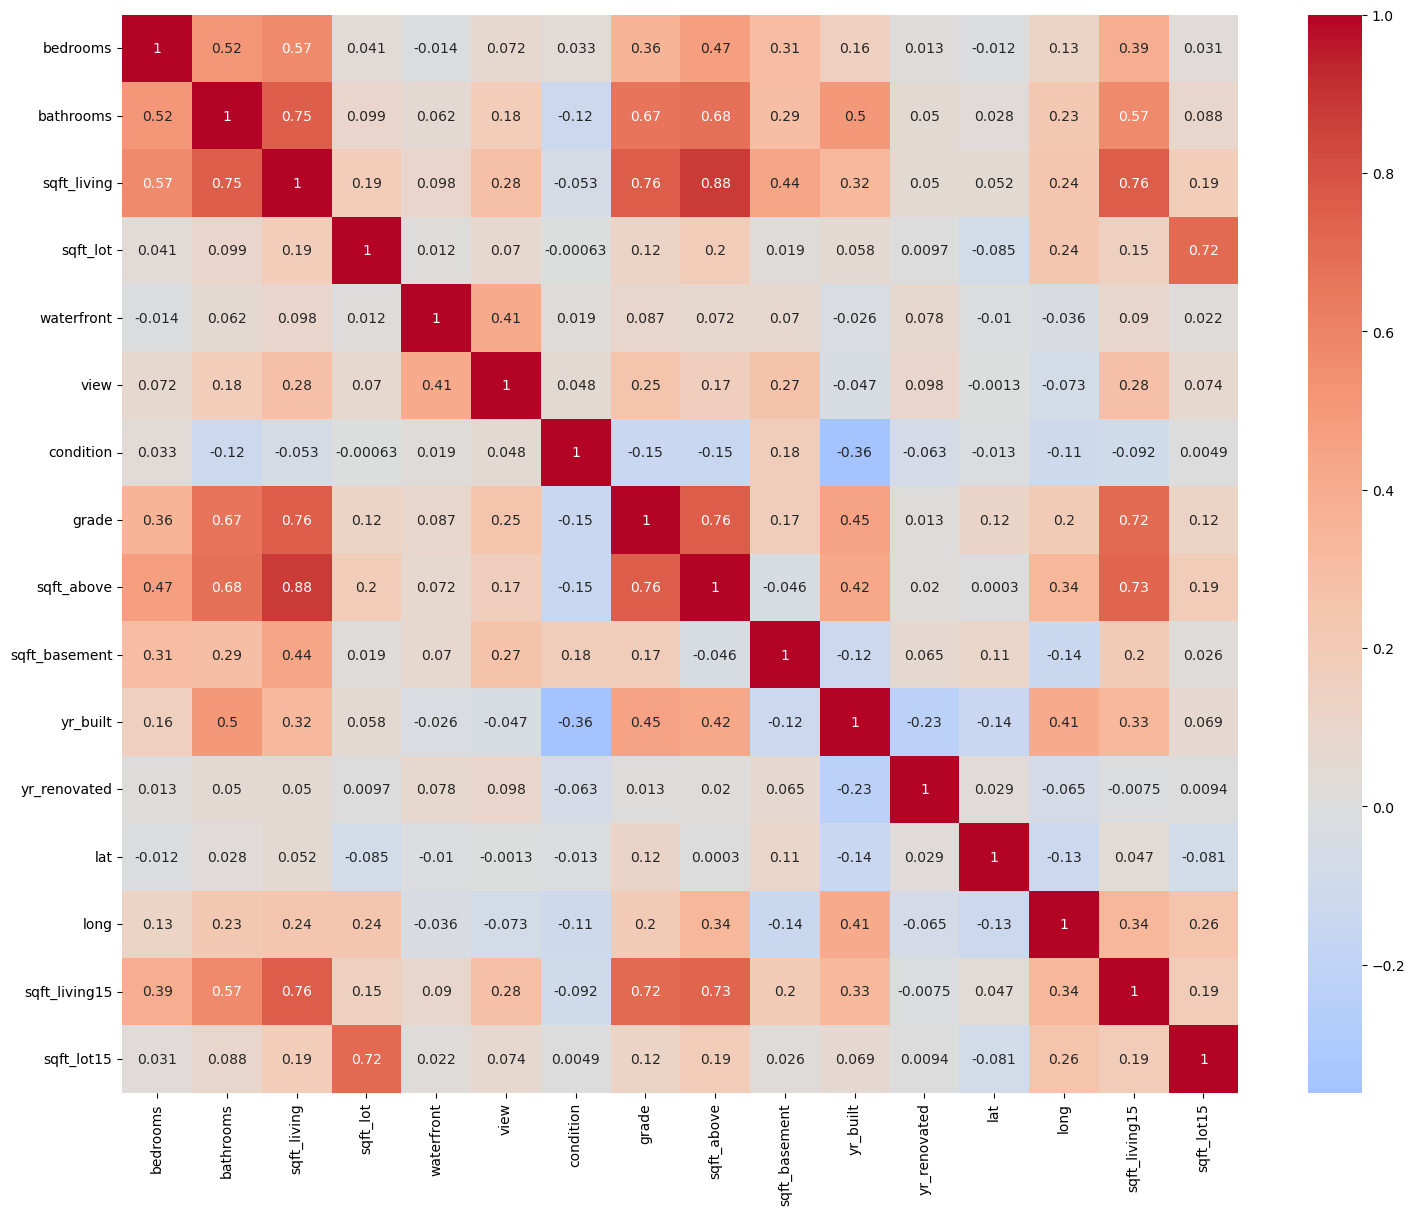

In [21]:
domy_train.drop('id', axis=1, inplace=True)
domy_test.drop('id', axis=1, inplace=True)

# Wybór tylko kolumn numerycznych do obliczenia korelacji
numCol = domy_train.select_dtypes(include=[np.number])
hmap = numCol.corr()
print(hmap)

plt.figure(figsize=(18, 14))
plt.subplot(1,1,1)
sns.heatmap(hmap, annot=True, cmap='coolwarm', center=0)

### Wnioski z korelacji.
1. Bardzo wysoka (0.88) jest korelacja pomiędzy **sqft_above** oraz **sqft_living**.
2. Inne cechy wysoko skorelowane to:
    - **sqft_living** i **bathrooms** o korelacji 0.75
    - **sqft_living** i **grade** o korelacji 0.76
    - **sqft_living15** i **grade** o korelacji 0.72
    - **sqft_living15** i **sqft_above** o korelacji 0.73
    - **sqft_above** i **grade** o korelacji 0.76
3. Cechą która najbardziej zasługuje na usunięcie przez jej najwyższe stopnie korelacji jest **sqft_living**.

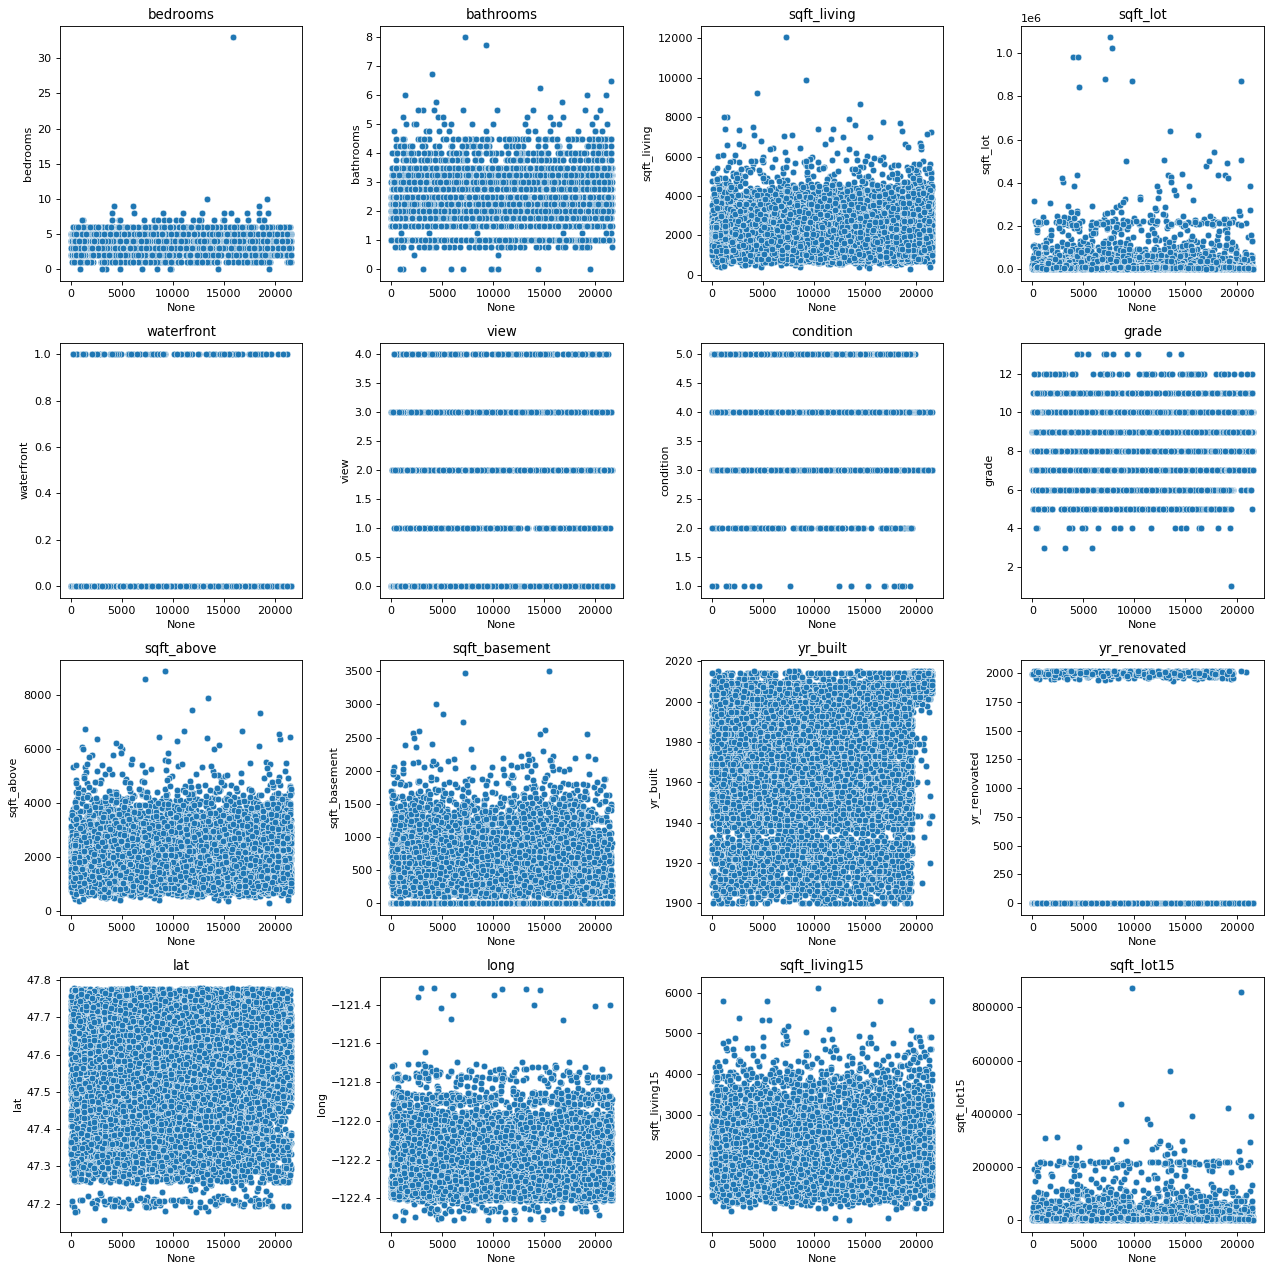

In [22]:
numCol = domy_train.select_dtypes(include=[np.number])
num_cols = numCol.columns
cols = 4
n = len(num_cols)
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows), dpi=80)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.scatterplot(x=domy_train.index, y=domy_train[col], ax=ax)
    ax.set_title(col)

# ukryj puste osie jeśli jakieś pozostaną
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [23]:
domy_train.describe()

,bedrooms,bathrooms,sqft_living,sqft_lot,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
count,14480.000000,14480.000000,14480.000000,1.448000e+04,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000,14480.000000
mean,3.368992,2.109513,2076.534254,1.497169e+04,0.007597,0.233702,3.410497,7.649862,1787.158011,289.376243,1970.967472,86.966367,47.561354,-122.213871,1984.497238,12716.749102
std,0.944465,0.768583,919.425607,3.989378e+04,0.086830,0.766789,0.650777,1.177077,827.129630,441.679753,29.351696,407.450696,0.138384,0.140740,686.013831,27362.767890
min,0.000000,0.000000,290.000000,5.200000e+02,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,47.155900,-122.512000,399.000000,651.000000
25%,3.000000,1.500000,1420.000000,5.053750e+03,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,47.472075,-122.329000,1480.000000,5100.000000
50%,3.000000,2.250000,1910.000000,7.607000e+03,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,47.573200,-122.231000,1840.000000,7620.000000
75%,4.000000,2.500000,2550.000000,1.071025e+04,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,47.679700,-122.125000,2360.000000,10095.250000
max,33.000000,8.000000,12050.000000,1.074218e+06,1.000000,4.000000,5.000000,13.000000,8860.000000,3500.000000,2015.000000,2015.000000,47.777600,-121.315000,6110.000000,871200.000000


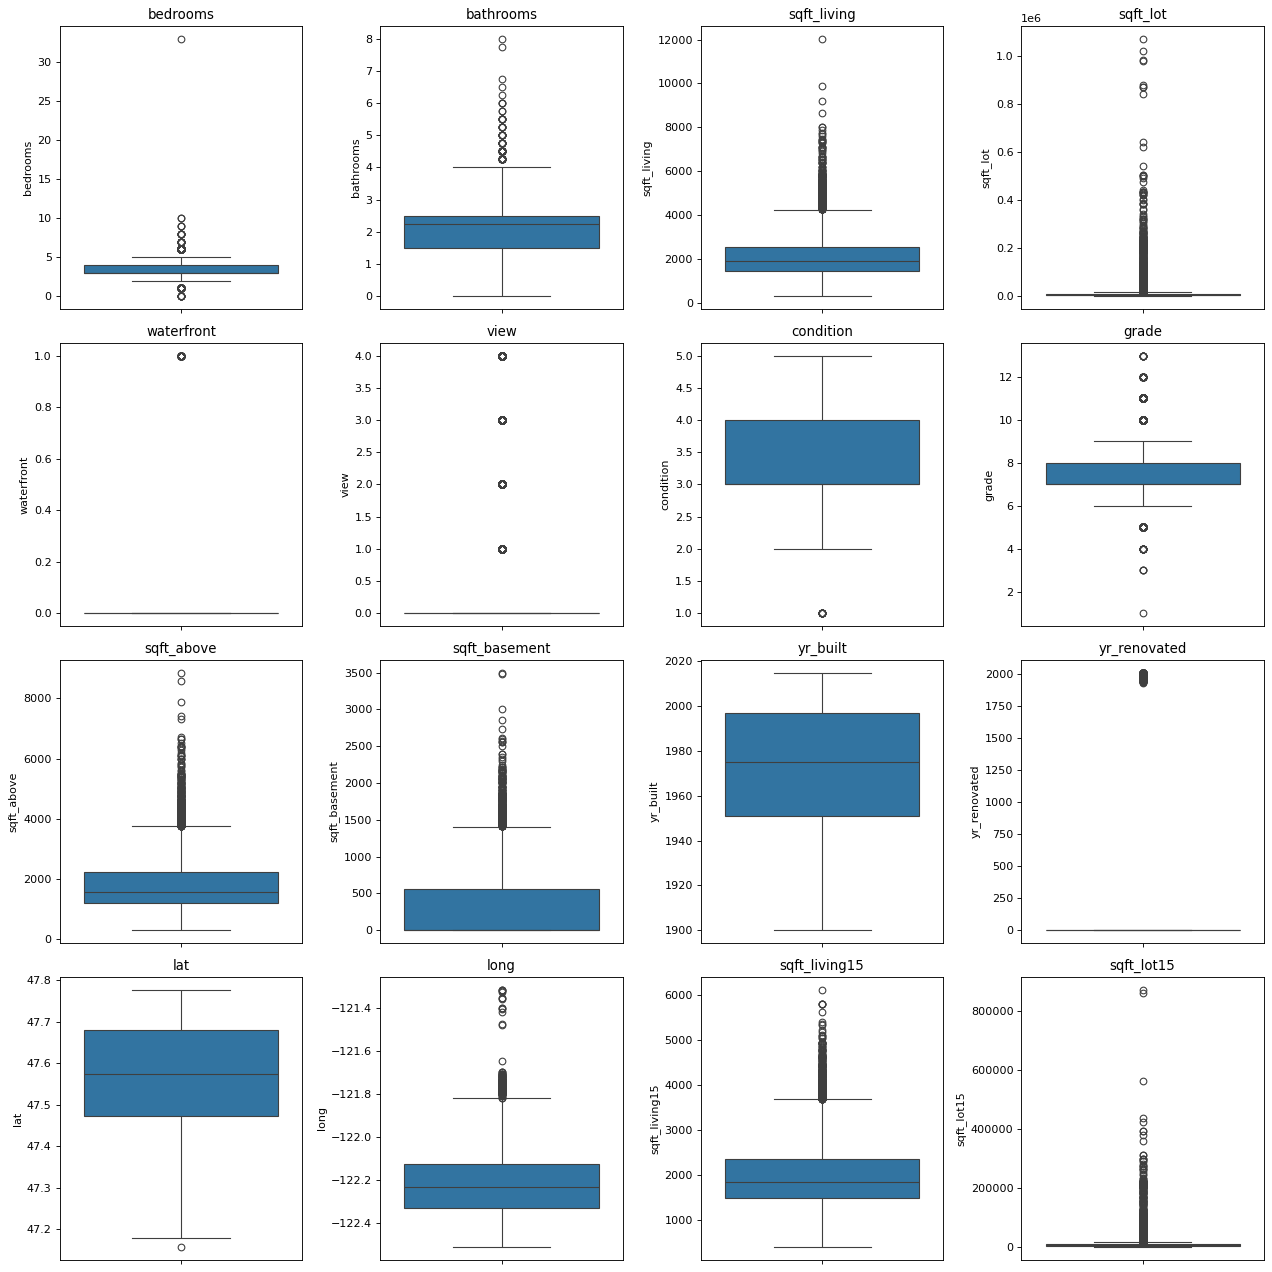

In [24]:
cols = 4
num_cols = numCol.columns
n = len(num_cols)
rows = int(np.ceil(n / cols))
plt.figure(figsize=(16, 4 * rows), dpi=80)
for i, atrybut in enumerate(num_cols):
    ax = plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=domy_train[atrybut], ax=ax)
    ax.set_title(atrybut)
plt.tight_layout()

### Wnioski ze statystyk
- **bedrooms** = średnia w ich wypadku jest wyższa niż mediana, sugeruje to większą liczebność danych o mniejszej liczbie sypialni.
- **bathrooms** = ich średnia liczba również jest wyższa  od mediany, ale różnica między średnią a 3 kwartylem jest dla łazienek mniejsza niż dla sypialni.
- **sqft_living** = średnia tego atrybutu jest wyższa od mediany o ok 1/10 swojej wartości, sugeruje to większą liczność danych o większej wartości atrybutu.
- **sqft_lot** = średnia tego atrybutu jest niemal o połowę wyższa od 3 kwartyla.
- **waterfront** = to w gruncie rzeczy atrybut binarny, oznaczający dostęp do wody lub jego brak.
- **view** = atrybut nie występujący w ponad 75% rekordów, ale przyjmujący różne wartości a nie binarny.
- **condition** = co najmniej 25% rekordów jest o wartości 3, pomiędzy 25% a 50%.
- **grade** =  co najmniej 50% wartości tego atrybutu w przedziale 25% do 75% jest o wartości 7 lub 8, średnia wartość również przypada na około 7.7 co sugeruje dość równomierny rozkład.
- **sqft_above** = średnia dla tego atrybutu jest wyższa od jego mediany, sugeruje to dominację elementów o wyższej wartości w obrębie atrybutu.
- **sqft_basement** = mniej niż 50% domów posiada piwnicę, przez co jej wielkość średnia jest 2-krotnie niższa od wartości trzeciego kwartylu oraz ponad 10-krotnie mniejsza niż maksymalna wartość.
- **yr_built** = przeważają młodsze domy, jedynie około jednego kwartyla domów zostało zbudowanych w najdłuższym okresie 1900-1951.
- **yr_renovated** = mniej niż 25% domów zostało odnowionych
- **lat** i **long** = położenie geograficzne, cechuje je niska wariancja oraz niewielka różnica między minimum a maksimum a więc domy znajdują się w jednym rejonie świata. Grupowanie na podstawie położenia może zwiększyć wydajność przewidywań przez wydzielenie dzielnic, które zwykle cechują się podobieństwem cen i warunków.
- **sqft_living15** = średnia jest wyraźnie skorelowana ze sqft_living i zwykle wyższa od mediany, co wskazuje na prawostronną skośność — kilka większych domów w sąsiedztwie podnosi wartość średnią; cecha dobrze opisuje kontekst lokalny powierzchni mieszkalnej.
- **sqft_lot15** = wysoka wariancja i średnia wyższa od mediany sugerują obecność kilku bardzo dużych działek (prawostronne rozproszenie); silna korelacja ze sqft_lot sprawia, że cecha odzwierciedla zróżnicowanie wielkości działek w otoczeniu.

In [25]:
numCol.skew()

bedrooms          2.546495
bathrooms         0.477735
sqft_living       1.418632
sqft_lot         11.689440
waterfront       11.343310
view              3.402625
condition         1.039314
grade             0.758231
sqft_above        1.444564
sqft_basement     1.531456
yr_built         -0.466715
yr_renovated      4.472324
lat              -0.485198
long              0.911067
sqft_living15     1.098425
sqft_lot15       10.422461
dtype: float64

### Wnioski skośność 
- Rzeczywiście zachodzi skośność ku prawej atrybutu **sqft_lot15**, ale również atrybutów **sqft_lot** oraz **waterfront**. Jako że wszystkie są atrybutami dodatnimi można je zlogarytmować lub zpierwiastować w celu zmniejszenia skośności.

In [26]:
domy_test['sqft_lot_log'] = np.log1p(domy_test['sqft_lot'].astype(float))
domy_train['sqft_lot_log'] = np.log1p(domy_train['sqft_lot'].astype(float))

domy_test['waterfront_log'] = np.log1p(domy_test['waterfront'].astype(float))
domy_train['waterfront_log'] = np.log1p(domy_train['waterfront'].astype(float))

domy_test['sqft_lot15_log'] = np.log1p(domy_test['sqft_lot15'].astype(float))
domy_train['sqft_lot15_log'] = np.log1p(domy_train['sqft_lot15'].astype(float))

#domy_train.drop(['sqft_lot', 'waterfront', 'sqft_lot15'], axis=1, inplace=True)

In [27]:
#domy_test.drop('sqft_living', axis=1, inplace=True)

## Zadanie 2
Napisz metodę regresji krokowej w tył i za jej pomocą wybierz 5 najbardziej wartościowych cech.

In [28]:
def backward_stepwise_regression(df, y, target_num=5, verbose=True):
    """
    Backward stepwise regression using ordinary least squares (no extra imports).
    Selects `target_num` numeric features from df to predict y.
    Returns selected feature names and coefficients (including intercept).
    """
    # Use only numeric predictors (avoid repeating imports/definitions)
    X_df = df.select_dtypes(include=[np.number]).copy()
    # Ensure alignment
    y_arr = y.loc[X_df.index].values.reshape(-1, 1)
    features = list(X_df.columns)

    # helper to fit OLS and compute RSS
    def fit_rss(feat_list):
        X = np.column_stack([np.ones(len(X_df)), X_df[feat_list].values])
        w = np.linalg.lstsq(X, y_arr, rcond=None)[0]
        resid = y_arr - X.dot(w)
        rss = float((resid ** 2).sum())
        return rss, w.flatten()

    # baseline with all numeric features
    baseline_rss, baseline_w = fit_rss(features)

    if verbose:
        print(f"Start features: {len(features)}, RSS: {baseline_rss:.3f}")

    # iteratively remove least important feature (that causes smallest increase in RSS)
    while len(features) > target_num:
        best_feat = None
        best_rss = None
        best_w = None
        best_delta = None

        for feat in features:
            cand = [f for f in features if f != feat]
            rss_cand, w_cand = fit_rss(cand)
            delta = rss_cand - baseline_rss
            if best_delta is None or delta < best_delta:
                best_delta = delta
                best_feat = feat
                best_rss = rss_cand
                best_w = w_cand

        # remove chosen feature
        features.remove(best_feat)
        baseline_rss = best_rss
        baseline_w = best_w
        if verbose:
            print(f"Removed: {best_feat} | New count: {len(features)} | RSS: {baseline_rss:.3f} | ΔRSS: {best_delta:.6f}")

    # final fit to return coefficients
    final_rss, final_w = fit_rss(features)
    intercept = final_w[0]
    coefs = final_w[1:]
    coef_series = { 'intercept': float(intercept) }
    coef_series.update({feat: float(c) for feat, c in zip(features, coefs)})

    return {
        'selected_features': features,
        'coefficients': coef_series,
        'rss': float(final_rss),
        'mse': float(final_rss / len(X_df))
    }

# Example usage (in this notebook environment):
result = backward_stepwise_regression(domy_train, ceny_train, target_num=5)
print(result['selected_features'])
print(result['coefficients'])

Start features: 19, RSS: 595811794914574.500
Removed: sqft_basement | New count: 18 | RSS: 595811794914573.625 | ΔRSS: -0.875000
Removed: waterfront | New count: 17 | RSS: 595811794914573.750 | ΔRSS: 0.125000
Removed: sqft_lot15 | New count: 16 | RSS: 595827275424124.750 | ΔRSS: 15480509551.000000
Removed: sqft_lot_log | New count: 15 | RSS: 596045314062990.750 | ΔRSS: 218038638866.000000
Removed: sqft_lot | New count: 14 | RSS: 596346471809131.375 | ΔRSS: 301157746140.625000
Removed: yr_renovated | New count: 13 | RSS: 596882605253590.500 | ΔRSS: 536133444459.125000
Removed: long | New count: 12 | RSS: 598096527781375.500 | ΔRSS: 1213922527785.000000
Removed: sqft_living15 | New count: 11 | RSS: 599655696834481.500 | ΔRSS: 1559169053106.000000
Removed: sqft_above | New count: 10 | RSS: 602985627610679.500 | ΔRSS: 3329930776198.000000
Removed: condition | New count: 9 | RSS: 606869632823577.875 | ΔRSS: 3884005212898.375000
Removed: sqft_lot15_log | New count: 8 | RSS: 610723532775478.2

## Zadanie 3
Korzystając z metody Lasso wybierz 5 najbardziej wartościowych cech z wszystkich cech wybranych w Zadaniu 1 + 5 zaproponowanych.

*Do wyznaczenia współczynników w tej metodzie należy zastosować metodę Spadku Koordynatów (ang. Coordinate Descent).*

*Wymagana w tej metodzie normalizacja cech może być ukryta w rozwiązaniu lub dokonana wcześniej.*

***!!! Normalizując zbiory unikaj informacji zawartej w zbiorze walidacyjnym i testowym !!!***

## Zadanie 4
Dla 5 wybranych w Zadaniu 3 cech dokonaj doboru współczynnika regularyzacji dla metody grzbietowej.

*Wyznaczenie współczynników można dokonać przy pomocy rozwiązania równania normalnego (należy pamiętać o pominięciu regularyzacji wyrazu wolnego). W przypadku złego uwarunkowania macierzy można zastosować metodę spadku gradientów, którą należy zaimplemntować samodzielnie.*

## Zadanie 5
Wytrenuj 5 modeli:
1. Wykorzystujący wszystkie cechy dane w zbiorze.
2. Wykorzystujący wszystkie cechy dane w zbiorze + 5 zaproponowanych.
3. Wykorzystujący 5 cech wybranych regresją krokową w tył.
4. Wykorzystujące tylko cechy wybrane dzięki metodzie Lasso.
5. Wykorzystujące cechy wybrane w metodzie Lasso i poddane regularyzacji grzbietowej dla wybranego współczynnika regularyzacji.

Porównaj średni błąd uczenia i testowania dla tych 5 modeli. Oceń, który model jest najlepszy.

*Wyznaczenie współczynników można dokonać przy pomocy rozwiązania równania normalnego (należy pamiętać o pominięciu regularyzacji wyrazu wolnego w metodzie grzbietowej). W przypadku złego uwarunkowania macierzy można zastosować metodę spadku gradientów, którą należy zaimplemntować samodzielnie.*

